# MDOF Mass-Spring System

## Exercise 1

3DoF mass-spring system with a harmonic excitation force to the third mass.

---
### Notes
### **Understanding the State-Space Formulation**

To solve a dynamic system using numerical integrators like `scipy.integrate.solve_ivp`, we must convert our high-level physics equations into a format the computer understands: the **State-Space Representation**.

#### **1. From Physics to Matrix Math**
The general equation for a Multi-Degree-of-Freedom (MDoF) system is:
$$M\mathbf{\ddot{x}} + K\mathbf{x} = \mathbf{F}(t)$$

A computer cannot "solve" a second-order derivative ($\mathbf{\ddot{x}}$) directly. It needs a formula that expresses the acceleration as a function of the current state. We rearrange the equation:

1.  **Isolate the Inertial Term:** $M\mathbf{\ddot{x}} = \mathbf{F}(t) - K\mathbf{x}$  
    *(Here, $\mathbf{F} - K\mathbf{x}$ represents the total net force acting on the masses).*

2.  **Solve for Acceleration:** To isolate $\mathbf{\ddot{x}}$, we multiply both sides by the inverse mass matrix $M^{-1}$:  
    $$\mathbf{\ddot{x}} = M^{-1}(\mathbf{F}(t) - K\mathbf{x})$$  
    *(This is essentially Newton's Second Law, $a = F/m$, expressed in matrix form).*



#### **2. Breaking Down the Python Code**
In the code, this operation is performed in a single, powerful line:
```python
accel = np.linalg.solve(M, F - K @ x)

* `np.linalg.solve(M, b)` — atrisina sistēmu $M\ddot{\mathbf{x}} = \mathbf{b}$
* The `@` Operator: In Python/NumPy, this is the Matrix Multiplication operator. Standard multiplication (`*`) would perform element-wise multiplication, which is incorrect for linear algebra.
* `K @ x`: This calculates the internal spring forces for all masses simultaneously based on their current positions.

#### Why this matters for Engineers

This approach is universal. Whether you have 3 masses or a complex bridge model with 3,000 nodes, the logic remains identical. You only need to build the $M$ and $K$ matrices; the integration logic stays the same.

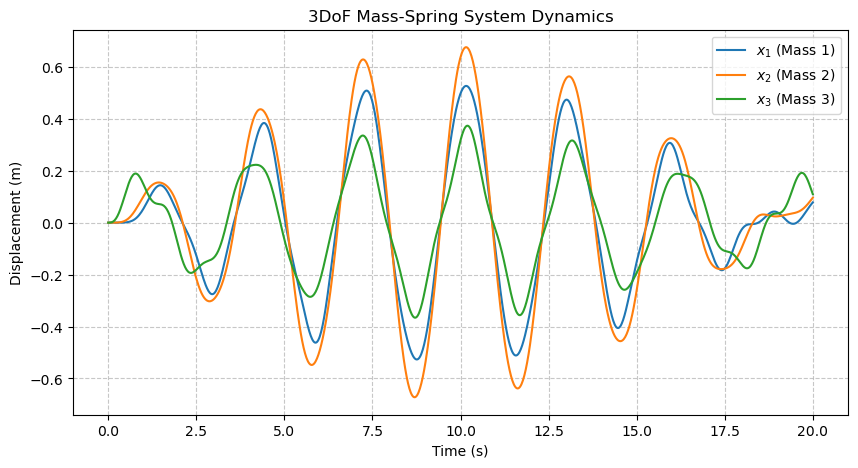

In [10]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# --- System Parameters ---
m = 1.0  # Base mass (kg)
k = 10.0 # Base spring constant (N/m)

# --- Mass Matrix (M) ---
# Represents the inertia of each cart.
M = np.array([[m, 0, 0],
              [0, 2*m, 0],
              [0, 0, m]])

# --- Stiffness Matrix (K) ---
# Represents the interaction forces between masses based on their displacements.
K = 


# --- External Forcing Function f(t) ---
# We apply a harmonic force to the third mass.
def f(t):
    return 5.0 * np.sin(2 * t) 

# --- State-Space ODE Definition ---
# solve_ivp requires first-order ODEs. 
# We define state vector y = [x1, x2, x3, v1, v2, v3]
def system_ode(t, y):
    x = y[:3] # Displacements
    v = y[3:] # Velocities
    
    # Force vector: only mass 3 is driven
    F = np.array([0, 0, f(t)])
    
    # Calculate acceleration: Ma = F - Kx
    accel = np.linalg.solve(M, F - K @ x)
    
    # Return derivatives: [dx/dt, dv/dt]
    return [*v, *accel]

# --- Numerical Integration ---
y0 = [0, 0, 0, 0, 0, 0] # Initial state: all masses at rest
t_span = (0, 20)        # Time interval for simulation
t_eval = np.linspace(0, 20, 1000) # Points where solution is stored

sol = solve_ivp(system_ode, t_span, y0, t_eval=t_eval)

# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(sol.t, sol.y[0], label='$x_1$ (Mass 1)')
plt.plot(sol.t, sol.y[1], label='$x_2$ (Mass 2)')
plt.plot(sol.t, sol.y[2], label='$x_3$ (Mass 3)')
plt.title('3DoF Mass-Spring System Dynamics')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Exercise 2

The Elastic Pendulum. This is a nonlinear system in which the radial and angular motions are coupled.

---
### Notes
### **Understanding the Non-linear Elastic Pendulum Dynamics**

Unlike the mass-spring system, the **Elastic Pendulum** is a non-linear system. This means the forces depend on the current state in a more complex way (using sines, cosines, and squared velocities), and we cannot representhemit with simple constant matrices.

#### **1. The Coupling of Two Motions**
The mass $m$ undergoes two types of motion simultaneously:
* **Radial motion ($r$):** The spring stretching and compressing.
* **Angular motion ($\theta$):** The swinging like a traditional pendulum.

These two motions are "coupled," meaning what happens in $r$ directly affects what happens in $\theta$, and viceversa.



#### **2. Decoding the Equations in Python**
In the `spring_pendulum_ode` function, we define the accelerations based on the Euler-Lagrange derivation:

**Radial Acceleration (`ddr`):**
$$
\ddot{r} = r \cdot \dot{\theta}^2 - \frac{K_{spring}}{M_{mass}} * (r - L_0) + G \cdot cos(\theta)
$$

**Angular Acceleration (`ddtheta`):**

$$
\ddot{\theta} = \frac{-G \cdot sin(\theta) - 2 \dot{r} \dot{\theta}}{r} 
$$

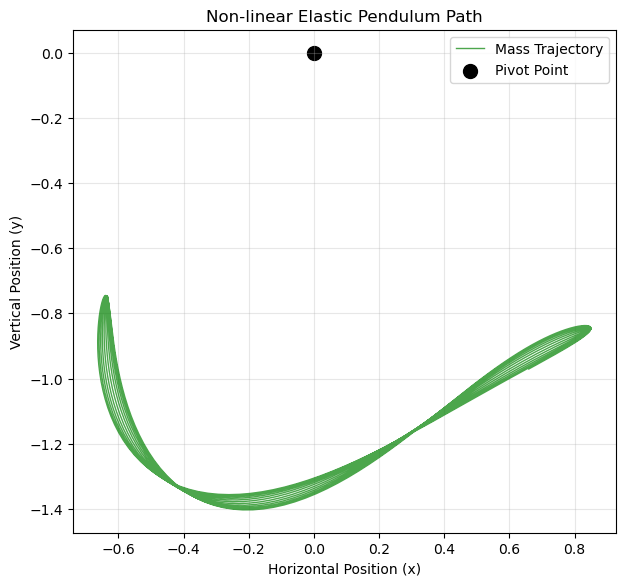

In [4]:
# --- System Constants ---
L0 = 1.0       # Unstretched (natural) length of the spring (m)
K_spring = 50.0 # Spring stiffness (N/m)
M_mass = 1.0    # Mass (kg)
G = 9.81        # Gravity (m/s^2)

# --- Non-linear ODE Definition ---
# State vector: [r, theta, dr, dtheta]
def spring_pendulum_ode(t, state):
    r, theta, dr, dtheta = state
    
    # 1. Radial Equation of Motion:
    # m*r'' - m*r*(theta')^2 + k(r - L0) - m*g*cos(theta) = 0
    # Rearranging for r'' (ddr):
    ddr = 
    
    # 2. Angular Equation of Motion:
    # r*theta'' + 2*r'*theta' + g*sin(theta) = 0
    # Rearranging for theta'' (ddtheta):
    ddtheta = 
    
    return [dr, dtheta, ddr, ddtheta]

# --- Numerical Integration ---
# Initial conditions: [r=1.2m, theta=45 degrees, dr=0, dtheta=0]
state0 = [1.2, np.pi/4, 0.0, 0.0]
t_span_p = (0, 15)
t_eval_p = np.linspace(0, 15, 1000)

sol_p = solve_ivp(spring_pendulum_ode, t_span_p, state0, t_eval=t_eval_p, method='RK45')

# --- Coordinate Transformation ---
# Convert polar coordinates (r, theta) to Cartesian (x, y) for plotting
x_p = sol_p.y[0] * np.sin(sol_p.y[1])
y_p = -sol_p.y[0] * np.cos(sol_p.y[1]) # Negative because y points down

# --- Visualization ---
plt.figure(figsize=(7, 7))
plt.plot(x_p, y_p, 'g-', linewidth=1, alpha=0.7, label='Mass Trajectory')
plt.scatter([0], [0], color='black', marker='o', s=100, label='Pivot Point')
plt.title('Non-linear Elastic Pendulum Path')
plt.xlabel('Horizontal Position (x)')
plt.ylabel('Vertical Position (y)')
plt.gca().set_aspect('equal') # Maintain 1:1 scale for physical accuracy
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Exercise 3

Two-Mass Spring Chain — Vibration Absorber

Mass $m_1$ sits on a spring $k_1$​ (attached to ground) and is driven by an external force $F(t) = F_0\cos(\omega t)$. A secondary mass $m_2$​ hangs from $m_1$​ via spring $k_2$​. This is the tuned mass damper — the device used in skyscrapers, bridges, and precision machinery to suppress resonance.

Demonstrate how a secondary mass $m_2$ can be "tuned" to act as a vibration absorber for the main structure $m_1$.
When $\omega$ matches the natural frequency of the main mass ($\sqrt{k_1/m_1}$), $m_1$ will oscillate violently. Your task is to show that, by correctly choosing $k_2$ and $m_2$, we can keep $m_1$ nearly perfectly still.

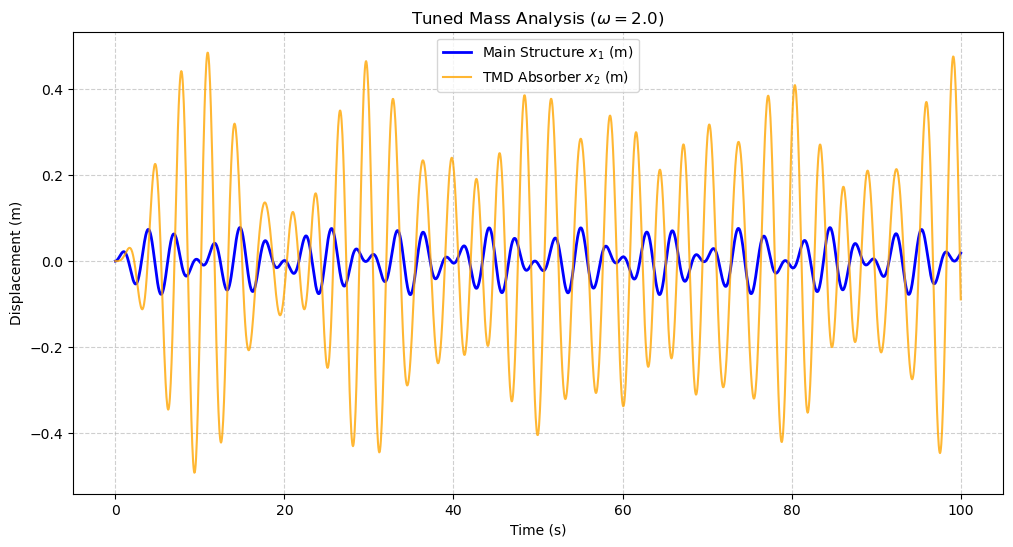

In [9]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# --- System Parameters ---
m1 = 100.0   # Main structure mass (kg)
k1 = 400.0   # Main structure stiffness (N/m)
m2 = 10.0    # Absorber mass (10% of m1)

# Tuning: Setting absorber frequency to match structure frequency
omega_n = np.sqrt(k1/m1) # Natural frequency of m1 (2.0 rad/s)
k2 = m2 * (omega_n**2)   # Tuned stiffness for the absorber
F0 = 10.0                # Force amplitude (N)
omega_drive = omega_n    # Driving exactly at resonance

# --- Matrix Definitions ---
## --- your code ---

# --- ODE Function (State-Space) ---
def tmd_matrix_ode(t, y):
    # Split state vector y into displacement (x) and velocity (v)
    x = y[:2]
    v = y[2:]
    
    # External force vector
    F = np.array([F0 * np.cos(omega_drive * t), 0])
    
    # Solve for acceleration: a = M^-1 * (F - Kx)
    accel = np.linalg.solve(M, F - K @ x)
    
    return [*v, *accel]

# --- Simulation ---
t_span = (0, 100)
t_eval = np.linspace(0, 100, 2000)
y0 = [0, 0, 0, 0] # Initial conditions (at rest)

sol = solve_ivp(tmd_matrix_ode, t_span, y0, t_eval=t_eval)

# --- Plotting ---
plt.figure(figsize=(12, 6))
plt.plot(sol.t, sol.y[0], label='Main Structure $x_1$ (m)', color='blue', linewidth=2)
plt.plot(sol.t, sol.y[1], label='TMD Absorber $x_2$ (m)', color='orange', alpha=0.8)

plt.title(fr'Tuned Mass Analysis ($\omega = {omega_drive}$)')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Independent Work

---


Use the Python code provided in the previous sections as a template to complete the following engineering challenges.

---

### **Assignment 1: Parametric Sensitivity in MDoF Systems**
**Objective:** Investigate how changing a physical parameter (Inertia) affects the overall vibbehaviourehavior of the 3DoF system.

**Tasks:**
1.  **Baseline Run:** Run the 3DoF code with the original parameters ($m=1.0, k=10.0$).
2.  **The "Heavy Middle" Scenario:** Modify the mass matrix so the second cart is much heavier: $m_2 = 10m$ (instead of $2m$).
3.  **Simulation:** Run the solver for 30 seconds.
4.  **Analysis:**
    * Plot the displacements of all three masses on one graph.
    * Observe the "Inertial Isolation": Does the heavy middle mass reduce the vibration transfer from the driven mass ($x_3$) to the first mass ($x_1$)?
    * **Question:** In mechanical engineering, why might we use a large "Inertial Block" to protect sensitive equipment from external vibrations?



---

### **Assignment 2: Resonance and Frequency Response**
**Objective:** Discover the "Natural Frequencies" of the 3DoF system by performing a manual frequency sweep.

**Tasks:**
1.  **Frequency Sweep:** The driving force $f(t)$ is currently set to $\sin(2t)$, where $\omega = 2 \text{ rad/s}$.
2.  **Experiment:** Run the simulation 5 times, changing the frequency $\omega$ in the `f(t)` function to: $1.0, 3.1, 4.5, 6.2, \text{ and } 8.0 \text{ rad/s}$.
3.  **Identify Resonance:** Find which frequency causes the highest displacement amplitude for the masses.
4.  **Engineering Challenge:** * If this system represented a building, and $x_3$ was a wind force, how would changing the stiffness $k$ help avoid resonance?
    * Briefly explain the relationship between stiffness and natural frequency.



---

### **Assignment 3: Energy Exchange in the Elastic Pendulum**
**Objective:** Observe the non-linear coupling between "swinging" and "bouncing" (The "Autoparametric Resonance").

**Tasks:**
1.  **The Rigid Limit:** Set `K_spring = 5000`. Observe the plot. Does the trajectory look like a perfect circle/arc?
2.  **The Coupling Effect:** Set `K_spring = 39.24` (this specifically targets a $2:1$ ratio between spring and pendulum frequency for $L_0=1$).
3.  **Initial Conditions:** Set the starting angle $\theta = 0.1 \text{ rad}$ and no initial stretch ($r = L_0$). 
4.  **Observation:**
    * Plot $r(t)$ and $\theta(t)$ as subplots.
    * Notice how the energy "bleeds" from the swing to the bounce and back again.
5.  **Reflection:** Why is this non-linear coupling (Coriolis and Centrifugal terms) a safety concern fo task describing the physical phenomenon you observed.

## Exercise 4

Now extend Exercise 3 by adding a damper $c_1$ between $m_1$ and the ground, and a damper $c_2$ between $m_1$ and $m_2$. This is the damped-tuned mass damper (TMD) — the version actually installed in real structures. Pure anti-resonance disappears, but the response near resonance becomes bounded, and the effective suppression band widens.

Analyse how adding damping ($c_1, c_2$) affects the resonance suppression and the stability of the structure. Observe the steady-state response of $m_1$ with and without damping. Identify how $c_2$ helps "broaden" the suppression range (making the system less sensitive to slight tuning errors).

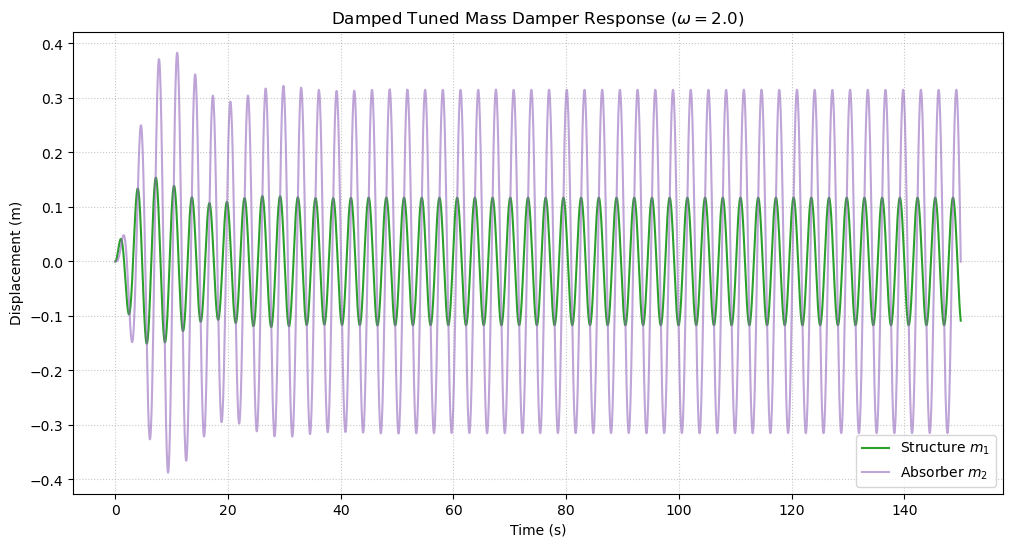

In [6]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# --- 1. System Parameters ---
m1, m2 = 100.0, 15.0       # Masses (kg)
k1, k2 = 400.0, 60.0       # Stiffness (N/m) - k2 tuned near resonance
c1 = 5.0                   # Damping of main structure (Ns/m)
c2 = 12.0                  # Damping of the absorber (Ns/m)

F0 = 20.0                  # Force amplitude (N)
omega_drive = 2.0          # Driving frequency (rad/s)

# --- 2. Matrix Formulation ---
## --- your code ---


# --- 3. ODE Definition (State-Space) ---
# State vector y = [x1, x2, v1, v2]
def damped_tmd_ode(t, y):
    x = y[:2]
    v = y[2:]
    
    # External force vector acting only on m1
    F = np.array([F0 * np.cos(omega_drive * t), 0])
    
    # M*a + C*v + K*x = F  =>  a = M^-1 * (F - C*v - K*x)
    accel = np.linalg.solve(M, F - C @ v - K @ x)
    
    return [*v, *accel]

# --- 4. Simulation ---
t_span = (0, 150)
t_eval = np.linspace(0, 150, 2500)
y0 = [0, 0, 0, 0] # Starting from rest

sol = solve_ivp(damped_tmd_ode, t_span, y0, t_eval=t_eval)

# --- 5. Visualization ---
plt.figure(figsize=(12, 6))
plt.plot(sol.t, sol.y[0], label='Structure $m_1$', color='#2ca02c')
plt.plot(sol.t, sol.y[1], label='Absorber $m_2$', color='#9467bd', alpha=0.6)

plt.title(fr'Damped Tuned Mass Damper Response ($\omega = {omega_drive}$)')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()